In [3]:
import colorsys
import re

def hsl_to_opencv_hsv(hsl_str):
    # Extract H, S, L values using regex
    match = re.match(r"hsl\((\d+)deg (\d+)% (\d+)%\)", hsl_str)
    if not match:
        raise ValueError("Invalid HSL format. Expected format: hsl(XXdeg XX% XX%)")
    
    h, s, l = map(int, match.groups())
    
    # Convert HSL to RGB (normalized)
    h, s, l = h / 360, s / 100, l / 100
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    
    # Convert RGB to OpenCV format (0-255)
    r, g, b = int(r * 255), int(g * 255), int(b * 255)
    
    # Convert RGB to HSV (normalized)
    r_norm, g_norm, b_norm = r / 255, g / 255, b / 255
    h, s, v = colorsys.rgb_to_hsv(r_norm, g_norm, b_norm)
    
    # Scale HSV values to OpenCV range
    h_opencv = int(h * 179)  # OpenCV uses 0-179 for H
    s_opencv = int(s * 255)  # OpenCV uses 0-255 for S
    v_opencv = int(v * 255)  # OpenCV uses 0-255 for V
    
    return (h_opencv, s_opencv, v_opencv)


In [ ]:
# Using a color picker app to find the hsl color value
hsl_color = "hsl(45deg 20% 52%)"
# Then convert it to OpenCV HSV
hsv_opencv = hsl_to_opencv_hsv(hsl_color)
print(f"OpenCV HSV: {hsv_opencv}")

OpenCV HSV: (21, 79, 157)


In [ ]:
import matplotlib.pyplot as plt
import colorsys

def hsv_to_rgb_opencv(h, s, v):
    h = h / 179.0  # Convert OpenCV Hue (0-179) to [0,1]
    s = s / 255.0  # Normalize saturation to [0,1]
    v = v / 255.0  # Normalize value to [0,1]
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    return int(r * 255), int(g * 255), int(b * 255)

def show_color(custom_params):
    # Extract custom HSV values
    hsv_ranges = {
        "Custom Min": (custom_params["custom_hue_min"], custom_params["custom_sat_min"], custom_params["custom_val_min"]),
        "Custom Max": (custom_params["custom_hue_max"], custom_params["custom_sat_max"], custom_params["custom_val_max"])
    }
    
    # Create a visualization of custom shades
    fig, ax = plt.subplots(1, len(hsv_ranges), figsize=(10, 2))
    
    if len(hsv_ranges) == 1:
        ax = [ax]  # Ensure ax is iterable when there's only one subplot
    
    for i, (label, hsv) in enumerate(hsv_ranges.items()):
        rgb = hsv_to_rgb_opencv(*hsv)  # Convert HSV to RGB
        ax[i].imshow([[rgb]], aspect='auto')
        ax[i].set_title(label, fontsize=10)
        ax[i].axis("off")
    
    plt.show()


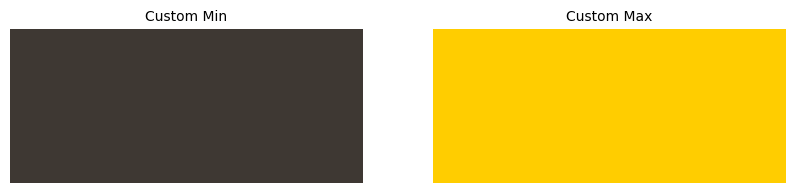

In [ ]:
# Shows the custom color range
custom_params = {
    "custom_hue_min": 16,
    "custom_sat_min": 45,
    "custom_val_min": 62,
    "custom_hue_max": 24,
    "custom_sat_max": 255,
    "custom_val_max": 255
}

show_color(custom_params)